# Data Exploration on a Food Hub Dataset

Analyze data from a food service delivery app business

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd
import math

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Allow python to display graphs inline
%matplotlib inline

#Restrict float values to 3 decimal places
pd.set_option('display.float_format', lambda x: '%0.3f' % x)


In [6]:
#Read csv data file
df = pd.read_csv("foodhub_order.csv")
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.750,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.080,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.230,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.590,Weekday,4,25,24


In [7]:
#understand the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   str    
 3   cuisine_type           1898 non-null   str    
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   str    
 6   rating                 1898 non-null   str    
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 133.6 KB


In [9]:
df.shape

(1898, 9)

In [10]:
#Generate statistical summary of the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.000,1477495.500,548.050,1476547.000,1477021.250,1477495.500,1477969.750,1478444.000
customer_id,1898.000,171168.478,113698.140,1311.000,77787.750,128600.000,270525.000,405334.000
cost_of_the_order,1898.000,16.499,7.484,4.470,12.080,14.140,22.297,35.410
food_preparation_time,1898.000,27.372,4.632,20.000,23.000,27.000,31.000,35.000
delivery_time,1898.000,24.162,4.973,15.000,20.000,25.000,28.000,33.000


In [11]:
df.describe(exclude='number').T

,count,unique,top,freq
restaurant_name,1898,178,Shake Shack,219
cuisine_type,1898,14,American,584
day_of_the_week,1898,2,Weekend,1351
rating,1898,4,Not given,736


In [13]:
categories = ['rating']
for category in categories:
    print(df[category].value_counts())
    print(df[category].value_counts(normalize=True))


rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64
rating
Not given   0.388
5           0.310
4           0.203
3           0.099
Name: proportion, dtype: float64


In [ ]:
df_clean = df[df['rating'].apply(lambda x: str(x).isdigit())]


(1162, 9)

In [24]:
df_clean.shape

(1162, 9)

In [26]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1162 entries, 2 to 1896
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1162 non-null   int64  
 1   customer_id            1162 non-null   int64  
 2   restaurant_name        1162 non-null   str    
 3   cuisine_type           1162 non-null   str    
 4   cost_of_the_order      1162 non-null   float64
 5   day_of_the_week        1162 non-null   str    
 6   rating                 1162 non-null   str    
 7   food_preparation_time  1162 non-null   int64  
 8   delivery_time          1162 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 90.8 KB


In [30]:
def plot_histogram(data, column_name):
    plt.figure(figsize = (10,7))

    data[column_name] = data[column_name].astype('category')

    sns.countplot(data = data, x = column_name, order = data[column_name].value_counts().index)

    plt.xticks(rotation = 90)
    plt.show()



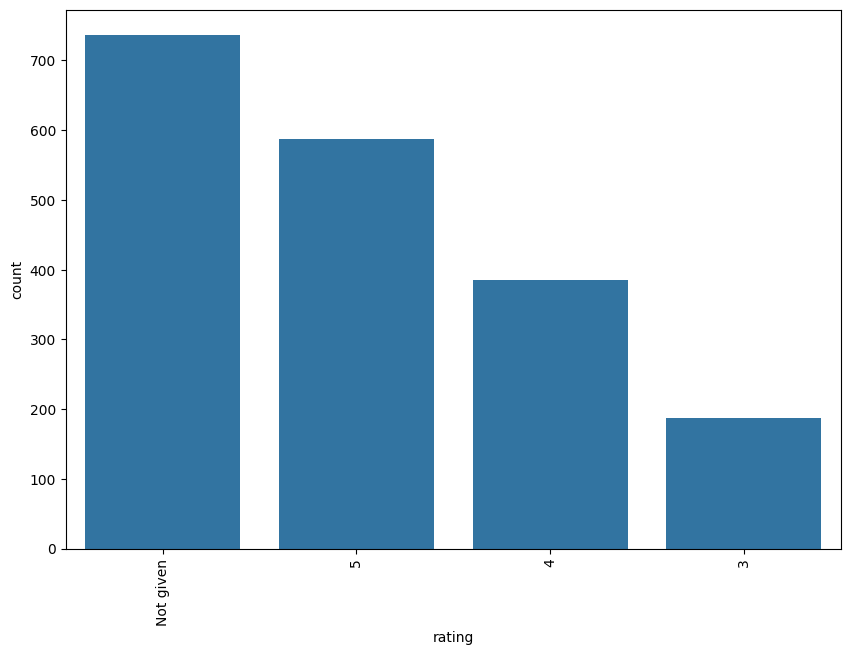

In [40]:
plot_histogram(df, 'rating') 

In [41]:
df['restaurant_name'].value_counts()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
                            ... 
Rye House                      1
Hiroko's Place                 1
Frank Restaurant               1
Sarabeth's West                1
'wichcraft                     1
Name: count, Length: 178, dtype: int64

In [35]:
df['day_of_the_week'].value_counts()

day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64

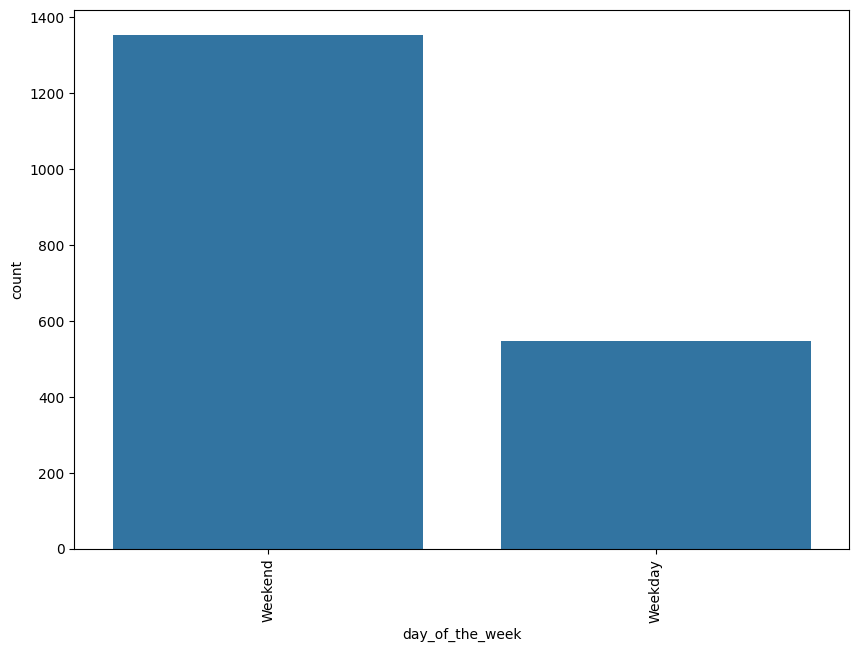

In [42]:
plot_histogram(df, 'day_of_the_week')

In [44]:
df['cuisine_type'].value_counts(normalize=True)

cuisine_type
American         0.308
Japanese         0.248
Italian          0.157
Chinese          0.113
Mexican          0.041
Indian           0.038
Middle Eastern   0.026
Mediterranean    0.024
Thai             0.010
French           0.009
Southern         0.009
Korean           0.007
Spanish          0.006
Vietnamese       0.004
Name: proportion, dtype: float64

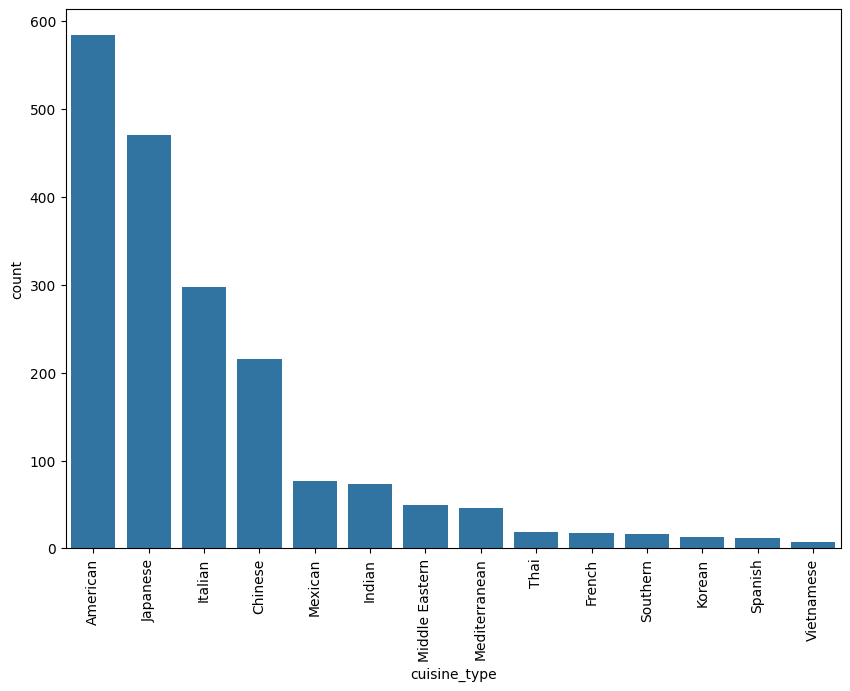

In [43]:
plot_histogram(df, 'cuisine_type')

## Observations
1. Most popular cuisine is American followed by Japanese

In [52]:
#Define method to plot histogram
def plot_histogram_continuous_data(data, column_name):
    figsize = (10,7)
    ax = sns.histplot(data=data, x=column_name, kde=True)
    mean_value = np.mean(data[column_name])
    median_value = np.median(data[column_name])
    ax.axvline(mean_value, color='g', linestyle='--', label='Mean')
    ax.axvline(median_value, color='m', linestyle='-',label='Median')

    plt.show()

    ay = sns.boxplot(data=data, x=column_name, showmeans=True)
    
    #calculate statistics and annotate the boxplot
    stats = data[column_name].describe()
    plt.show()

    print(stats)   



In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   order_id               1898 non-null   int64   
 1   customer_id            1898 non-null   int64   
 2   restaurant_name        1898 non-null   str     
 3   cuisine_type           1898 non-null   category
 4   cost_of_the_order      1898 non-null   float64 
 5   day_of_the_week        1898 non-null   category
 6   rating                 1898 non-null   category
 7   food_preparation_time  1898 non-null   int64   
 8   delivery_time          1898 non-null   int64   
dtypes: category(3), float64(1), int64(4), str(1)
memory usage: 95.4 KB


In [50]:
df[['cost_of_the_order','food_preparation_time','delivery_time']].describe().T

,count,mean,std,min,25%,50%,75%,max
cost_of_the_order,1898.000,16.499,7.484,4.470,12.080,14.140,22.297,35.410
food_preparation_time,1898.000,27.372,4.632,20.000,23.000,27.000,31.000,35.000
delivery_time,1898.000,24.162,4.973,15.000,20.000,25.000,28.000,33.000


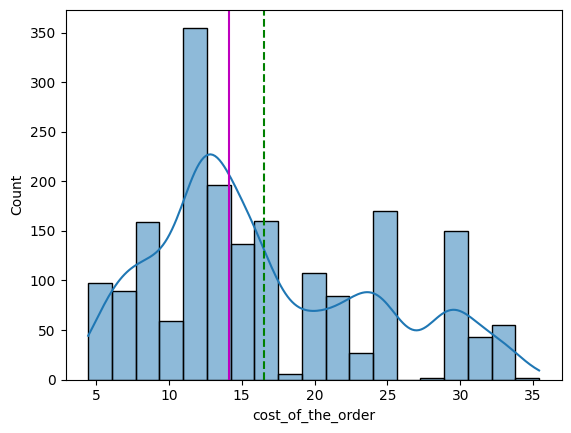

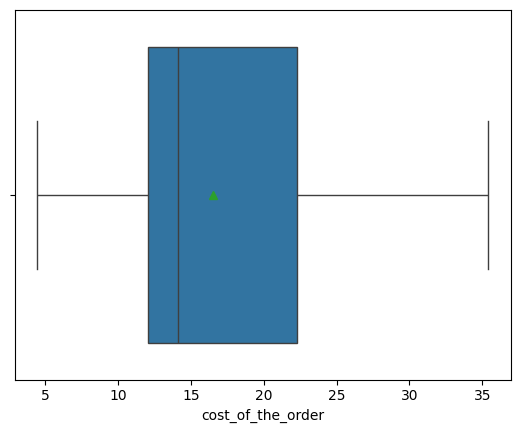

count   1898.000
mean      16.499
std        7.484
min        4.470
25%       12.080
50%       14.140
75%       22.297
max       35.410
Name: cost_of_the_order, dtype: float64


In [53]:
plot_histogram_continuous_data(df,'cost_of_the_order')

## Observations
1. Mean is skewed to a higher value compared to the median by high cost orders

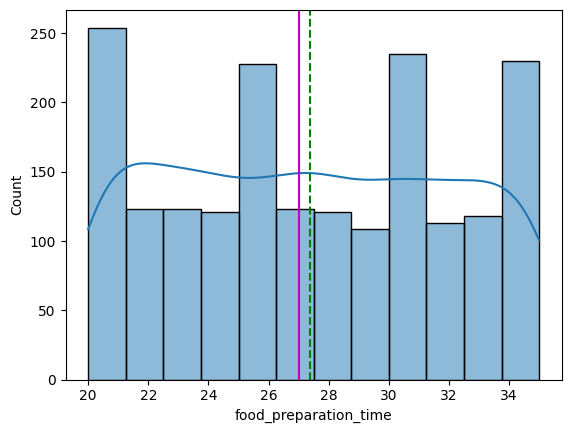

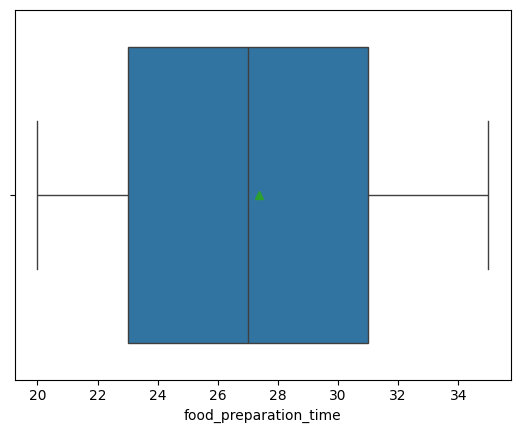

count   1898.000
mean      27.372
std        4.632
min       20.000
25%       23.000
50%       27.000
75%       31.000
max       35.000
Name: food_preparation_time, dtype: float64


In [54]:
plot_histogram_continuous_data(df, 'food_preparation_time')

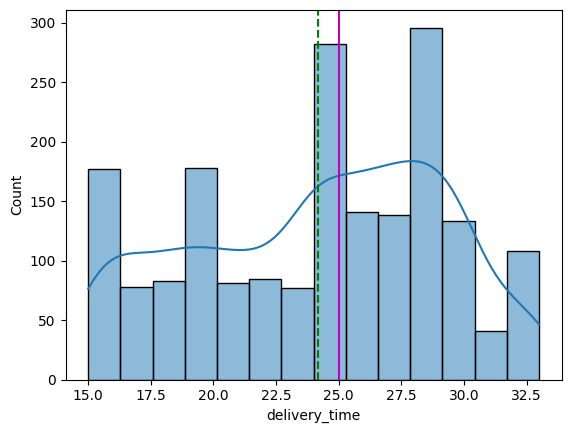

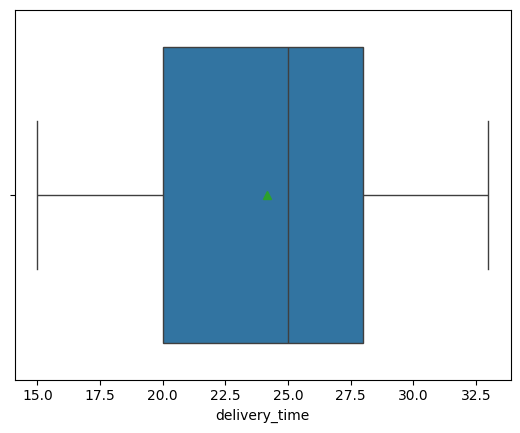

count   1898.000
mean      24.162
std        4.973
min       15.000
25%       20.000
50%       25.000
75%       28.000
max       33.000
Name: delivery_time, dtype: float64


In [55]:
plot_histogram_continuous_data(df, 'delivery_time')

## Examine the top 5 restuarants in terms of orders recieved

In [56]:
df['restaurant_name'].value_counts().head()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

## Most popular cuisine on weekends

In [63]:
df['day_of_the_week'].value_counts()
df_weekend_orders = df[df['day_of_the_week'].isin(['Weekend'])]
df_weekend_orders.shape
df_weekend_orders['cuisine_type'].value_counts()


cuisine_type
American          415
Japanese          335
Italian           207
Chinese           163
Mexican            53
Indian             49
Mediterranean      32
Middle Eastern     32
Thai               15
French             13
Korean             11
Southern           11
Spanish            11
Vietnamese          4
Name: count, dtype: int64

The most popular cuisine during the weekend is American

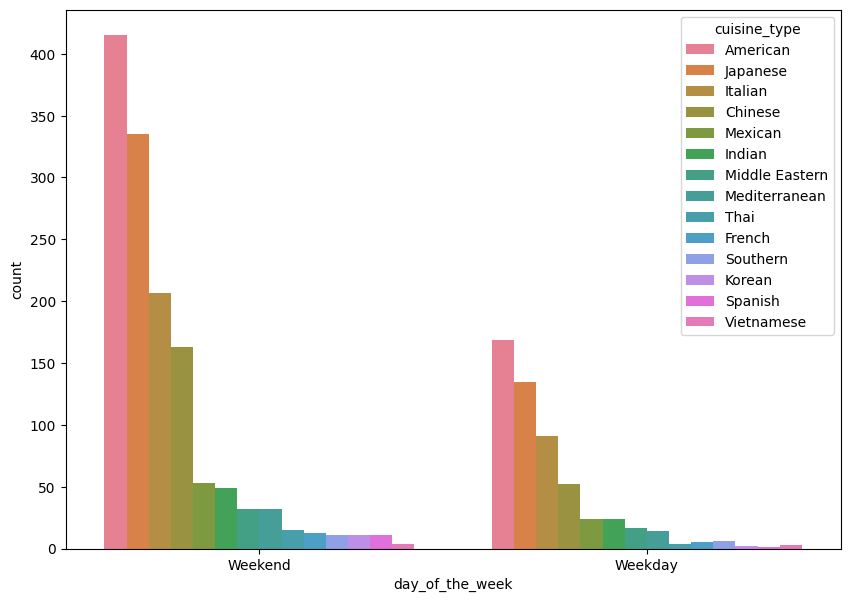

In [ ]:
plt.figure(figsize = (10,7))
sns.countplot(data=df,x='day_of_the_week',hue='cuisine_type',
              order=df['day_of_the_week'].value_counts().index, 
              hue_order=df['cuisine_type'].value_counts().index)
plt.show()

## Percentage of orders that cost more that $20


In [74]:
count_of_orders_costing_more_than_20 = df[df['cost_of_the_order'] > 20]
count_of_orders_costing_more_than_20.shape
#Percentage of orders costing more than $10
round(count_of_orders_costing_more_than_20.shape[0]/df.shape[0] * 100, 2)


29.24

## Mean order delivery time

In [79]:
# Mean order delivery time
print(f"{round(np.mean(df['delivery_time']), 2)}%")

24.16%


In [80]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.000,1477495.500,548.050,1476547.000,1477021.250,1477495.500,1477969.750,1478444.000
customer_id,1898.000,171168.478,113698.140,1311.000,77787.750,128600.000,270525.000,405334.000
cost_of_the_order,1898.000,16.499,7.484,4.470,12.080,14.140,22.297,35.410
food_preparation_time,1898.000,27.372,4.632,20.000,23.000,27.000,31.000,35.000
delivery_time,1898.000,24.162,4.973,15.000,20.000,25.000,28.000,33.000


The company has decided to give 20% discount vouchers to top 3 frequent customers. Find IDs of these customers and the number of orders that they placed

In [81]:
df['customer_id'].value_counts().head(3)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

## Multivariate analysis

In [89]:
#Method to create a heatmap

def create_heatmap(data):
    numeric_data = data.select_dtypes(include=[np.number])
    sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
    plt.show()



In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   order_id               1898 non-null   int64   
 1   customer_id            1898 non-null   int64   
 2   restaurant_name        1898 non-null   str     
 3   cuisine_type           1898 non-null   category
 4   cost_of_the_order      1898 non-null   float64 
 5   day_of_the_week        1898 non-null   category
 6   rating                 1898 non-null   category
 7   food_preparation_time  1898 non-null   int64   
 8   delivery_time          1898 non-null   int64   
dtypes: category(3), float64(1), int64(4), str(1)
memory usage: 95.5 KB


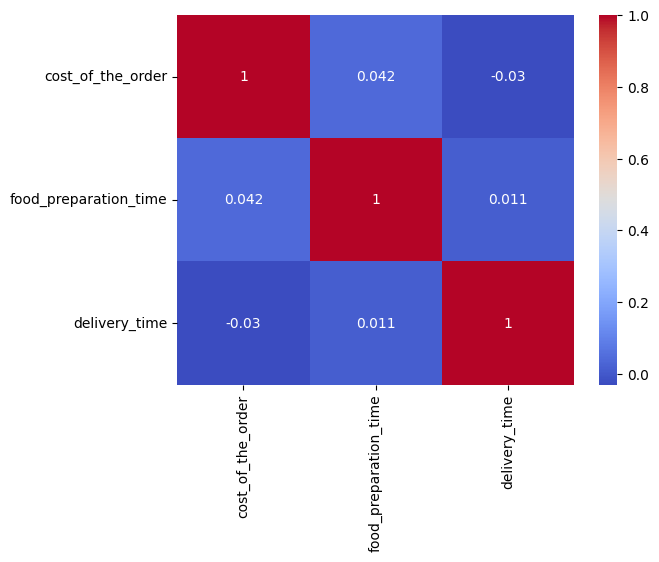

In [94]:
df_numeric_cols = df[['cost_of_the_order','food_preparation_time','delivery_time']]
create_heatmap(df_numeric_cols)

In [103]:
#creating a box plot between variables
def create_box_plot(data, x, y):
    plt.figure(figsize=(10,7))
    order = data.groupby(x)[y].median().sort_values(ascending=False).index
    sns.boxplot(data=data, x=x, y=y, order=order, palette='Set1', showmeans=True)
    plt.xticks(rotation = 90)

    plt.show()

/var/folders/vw/8_j9mnfx71sbn2ld3v_wz9180000gn/T/ipykernel_97653/3801202277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, order=order, palette='Set1', showmeans=True)


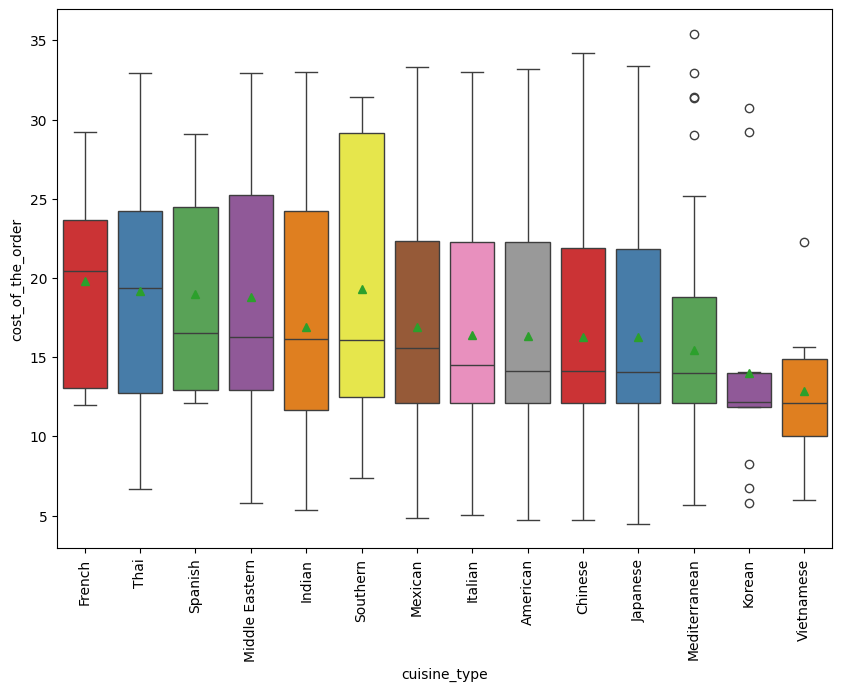

In [104]:
create_box_plot(df, 'cuisine_type', 'cost_of_the_order')

/var/folders/vw/8_j9mnfx71sbn2ld3v_wz9180000gn/T/ipykernel_97653/3801202277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, order=order, palette='Set1', showmeans=True)


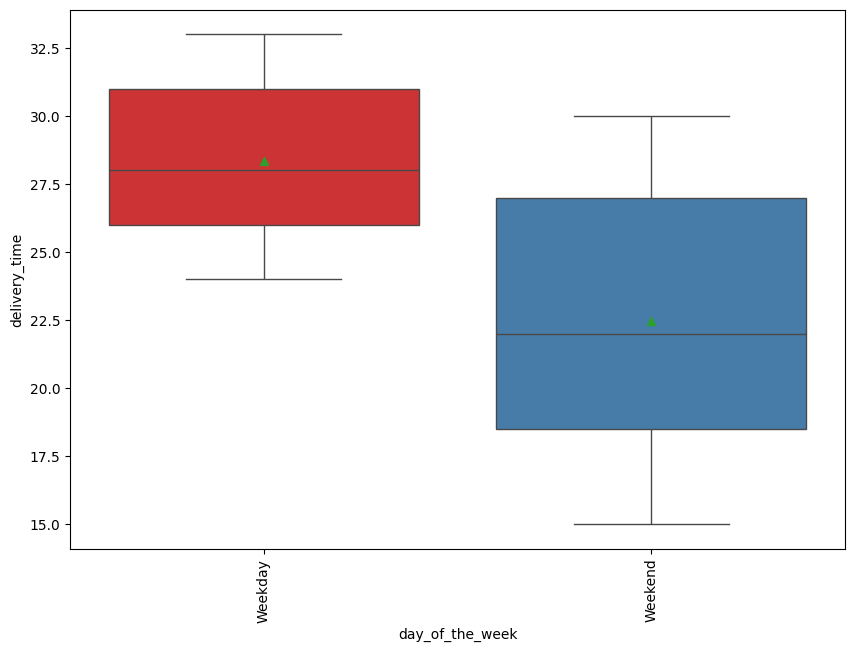

In [106]:
create_box_plot(df, 'day_of_the_week', 'delivery_time')

In [108]:
def create_point_plot(data, x, y):
    plt.figure(figsize=(10, 7))
    sns.pointplot(data=data, x=x, y=y)

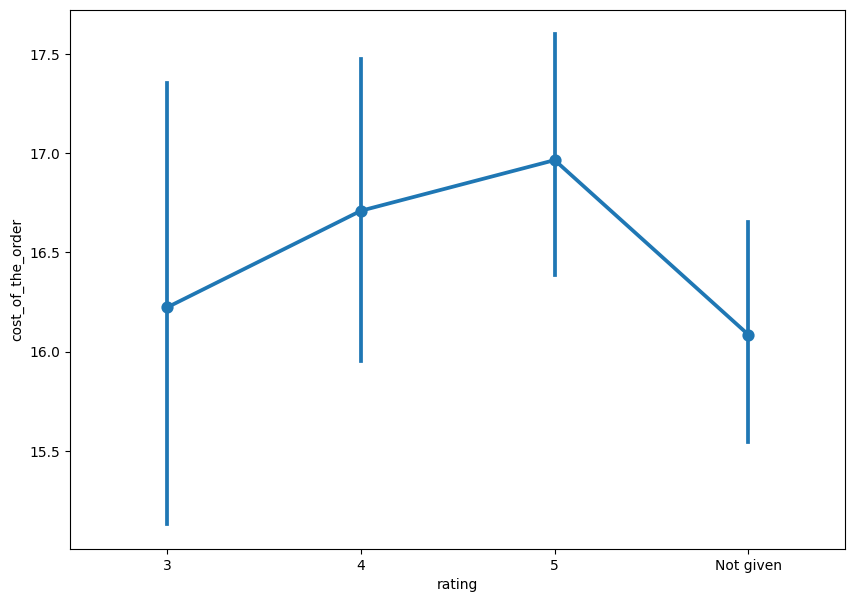

In [109]:
create_point_plot(df, 'rating', 'cost_of_the_order')

## Restuarant with the highest revenue

In [119]:
df['Revenue'] = df.groupby('restaurant_name')['cost_of_the_order'].transform('sum')
df[df['Revenue'] == df['Revenue'].max()]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Revenue
15,1477414,66222,Shake Shack,American,16.200,Weekend,5,33,25,3579.530
21,1478226,137565,Shake Shack,American,15.910,Weekend,Not given,25,20,3579.530
22,1478287,150599,Shake Shack,American,29.100,Weekday,5,21,30,3579.530
39,1476891,220693,Shake Shack,American,19.890,Weekend,Not given,27,19,3579.530
64,1478077,82041,Shake Shack,American,33.030,Weekday,Not given,22,32,3579.530
...,...,...,...,...,...,...,...,...,...,...
1881,1476700,127036,Shake Shack,American,12.230,Weekend,Not given,27,18,3579.530
1884,1477437,304993,Shake Shack,American,31.430,Weekend,3,31,24,3579.530
1885,1477550,97324,Shake Shack,American,29.050,Weekday,4,27,29,3579.530
1887,1476873,237616,Shake Shack,American,5.820,Weekend,Not given,26,30,3579.530


In [120]:
print(f"Shake Shack has the highest revenue of ${round(df['Revenue'].max(), 2)}")

Shake Shack has the highest revenue of $3579.53


## Restuarant with the highest number of orders

In [123]:
df['order_count'] = df.groupby('restaurant_name')['restaurant_name'].transform('count')
df[df['order_count'] == df['order_count'].max()].head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Revenue,order_count
15,1477414,66222,Shake Shack,American,16.200,Weekend,5,33,25,3579.530,219
21,1478226,137565,Shake Shack,American,15.910,Weekend,Not given,25,20,3579.530,219
22,1478287,150599,Shake Shack,American,29.100,Weekday,5,21,30,3579.530,219
39,1476891,220693,Shake Shack,American,19.890,Weekend,Not given,27,19,3579.530,219
64,1478077,82041,Shake Shack,American,33.030,Weekday,Not given,22,32,3579.530,219


In [124]:
print(f"Shake Shack has the highest number of orders with value {df['order_count'].max()}")

Shake Shack has the highest number of orders with value 219


In [129]:
#Create a function to plot a scatter plot
def create_scatter_plot(data, x, y, z):
    plt.figure(figsize = (10,7))
    sns.scatterplot(data=data, x=x, y=y, hue=z)
    plt.show()

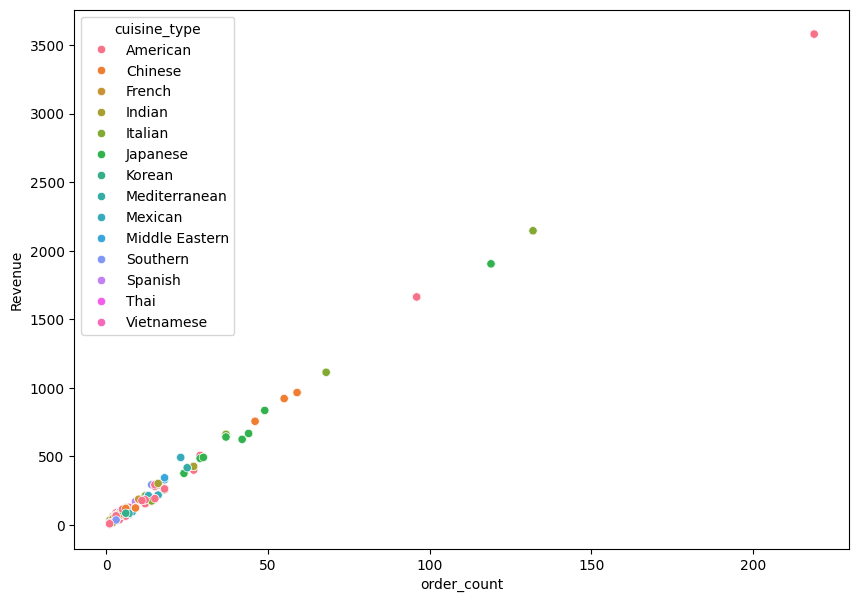

In [130]:
create_scatter_plot(df,'order_count', 'Revenue', 'cuisine_type')

To increase revenue, a restaurant should strive to increase the number of orders